In [1]:
from starccato_flow.training.trainer_flow_matching_multi import FlowMatchingTrainerMulti
from starccato_flow.supernovae.supernovae import Supernovae
from starccato_flow.utils.defaults import TEN_KPC
import numpy as np

MPS device found


/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
font_family = "sans-serif"
font_name = "avenir"

In [3]:
supernovae_complex = Supernovae(locations_file='../../data/supernovae/exploded_supernovae_t100_sf5.csv', rotation_offset=np.deg2rad(60.0))

✓ Loaded 1934076 supernova locations from ../../data/supernovae/exploded_supernovae_t100_sf5.csv


In [4]:
supernovae_complex.plot_galactic_distribution(
    fname_xy="../../poster-presentation/supernovae_distribution_kpc.png",
    transparent=True,
    light_year=False,
    figsize=(20, 20),
    font_family=font_family,
    font_name=font_name,
)

supernovae_complex.plot_galactic_distribution(
    fname_xy="../../poster-presentation/supernovae_distribution_light_years.png",
    transparent=True,
    light_year=True,
    figsize=(20, 20),
    font_family=font_family,
    font_name=font_name,
)

[<Figure size 2000x2000 with 1 Axes>,
 <Figure size 2000x2000 with 1 Axes>,
 <Figure size 2000x2000 with 1 Axes>]

In [5]:
trainer_sky = FlowMatchingTrainerMulti(num_epochs=256, toy=False, parameters=["ra", "dec", "d", "psi"])
trainer_sky.load_model_instance(model_path="../outdir/flow_sky_weights_test.pt")


=== Parameter Extraction Setup ===
Requested parameters: ['ra', 'dec', 'd', 'psi']
Intrinsic params: []
Sky params: ['ra', 'dec', 'd', 'psi']
Extract indices (sequential from hThetaMulti): [0, 1, 2, 3]
Final flow parameter dimension: 4

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv

sTheta Dataset - Parameter Bounds (0 parameters)


=== Data Split ===
Total signals: 1684
Training signals: 1516
Validation signals: 168
First 5 training indices: [ 360  336   81  684 1374]
First 5 validation indices: [722 519 222  32 111]

sTheta Dataset - Parameter Bounds (0 parameters)


sTheta Dataset - Parameter Bounds (0 parameters)


Verifying data alignment:
Number of signals: 1516
Number of parameter sets: 1516
Parameter names: []
First few parameter values:
[]

Verifying data alignment:
Number of signals: 168
Number of parameter sets: 168
Parameter names: []
First few parameter values:
[]

=== D

Loaded 256 training loss entries from /Users/tarineccleston/Desktop/starccato/starccato-flow/outdir/flow_matching/losses.csv


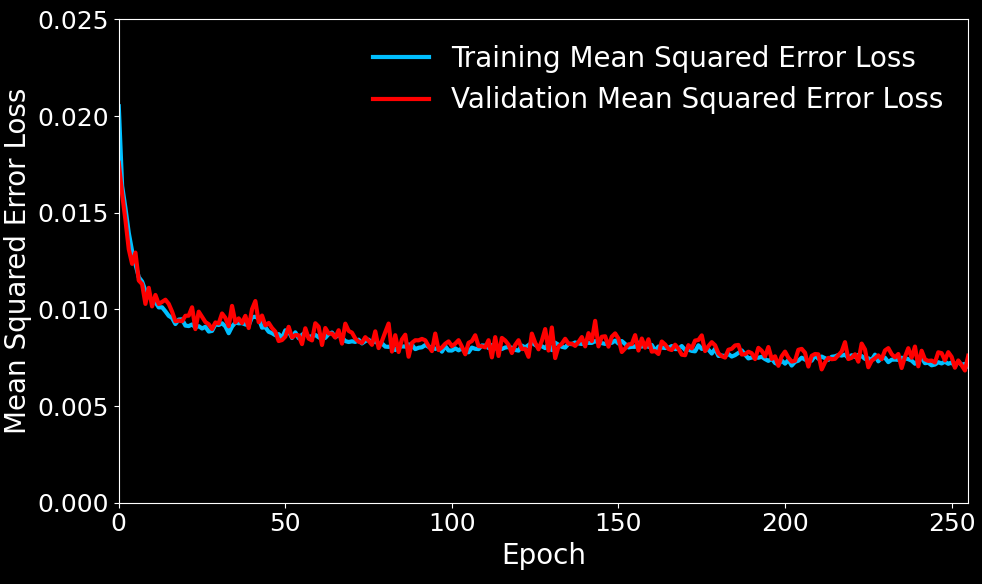

In [6]:
trainer_sky.load_losses()
trainer_sky.display_results(fname="../../poster-presentation/flow_sky_results.png", font_family=font_family, font_name=font_name, background="black")


hThetaMulti Dataset - Parameter Bounds (4 parameters)
INTRINSIC PARAMETERS:

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [   -3.141593,     3.141593]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    10.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 1
Multi-channel shape: (1, 3, 256)
Parameter dimension: 4
Parameters include theta + sky: [ra, dec, d, polar_angle]


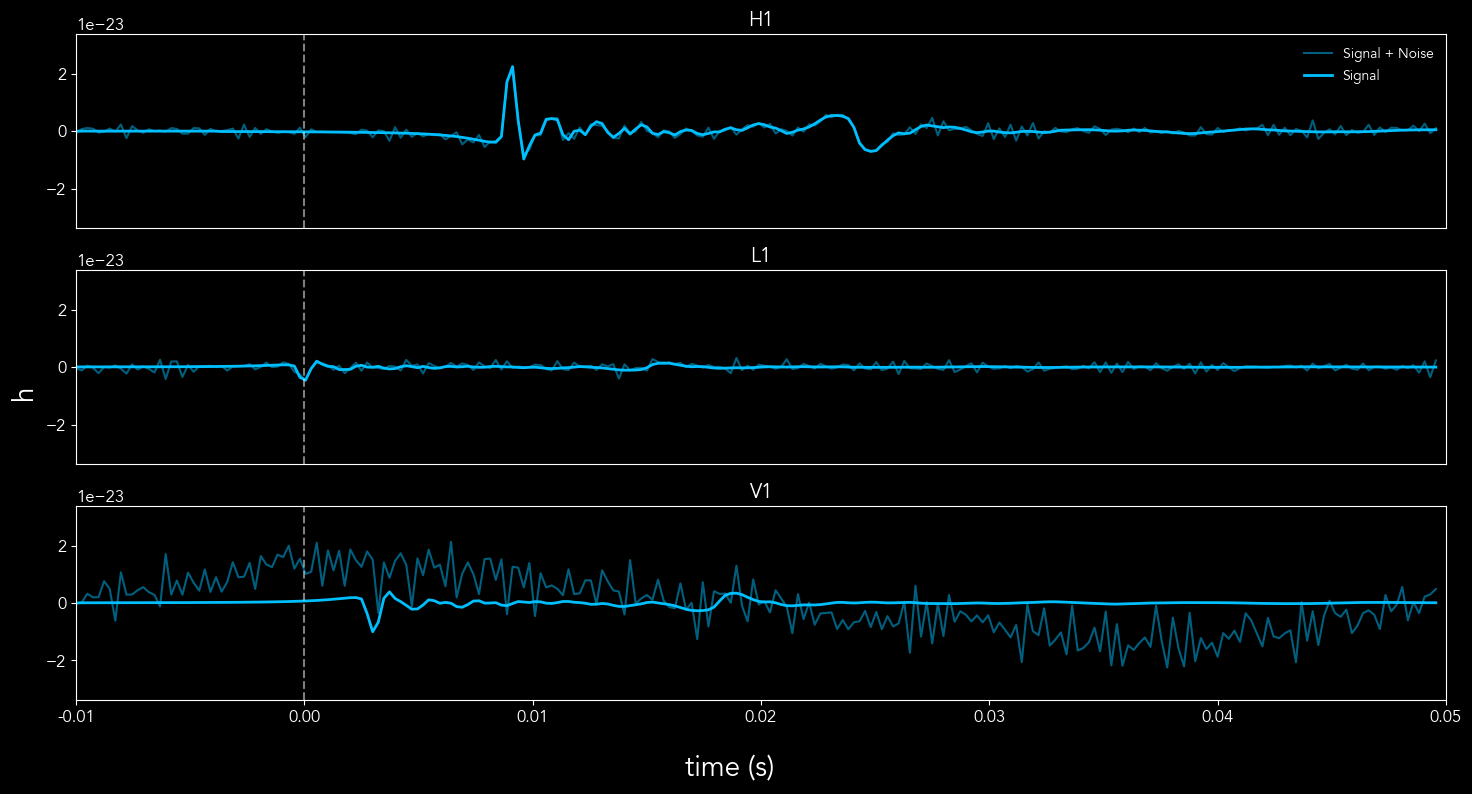

Posterior sampling and denormalisation took 0.40s

Plot axis ranges (extracted parameter space):
  ra                  : (-3.3300883769989014, 3.3300883769989014)
  dec                 : (-1.6650441884994507, 1.6650441884994507)
  d                   : (-0.29999998211860657, 10.300000190734863)
  psi                 : (-0.09424778074026108, 3.2358405590057373)
  Override d range to: (0.1, 10.0)

Debug: Validating ranges and samples...
  Posterior samples shape: (3000, 4)
  True param shape: (4,)
  Number of ranges: 4
  Number of sample dimensions: 4
  NaN values in samples: 0
  Inf values in samples: 0
  Validating ranges:
    Range 0: (-3.3301, 3.3301) ✓
      Sample range: [1.9137, 2.9206]
    Range 1: (-1.6650, 1.6650) ✓
      Sample range: [-1.0640, -0.5154]
    Range 2: (0.1000, 10.0000) ✓
      Sample range: [1.8957, 11.4515]
    Range 3: (-0.0942, 3.2358) ✓
      Sample range: [0.9716, 2.2050]


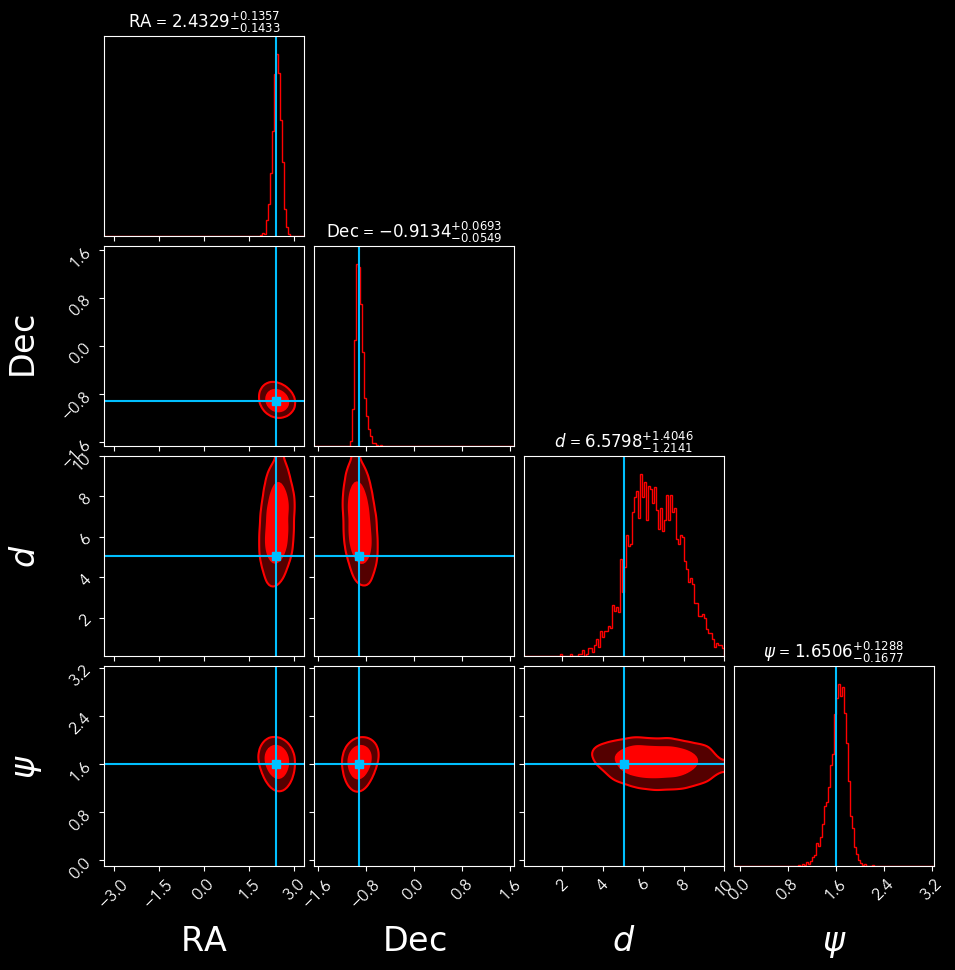


Galactic Center Direction:
  RA:  2.730630 rad = 156.45°
  Dec: -1.048155 rad = -60.05°



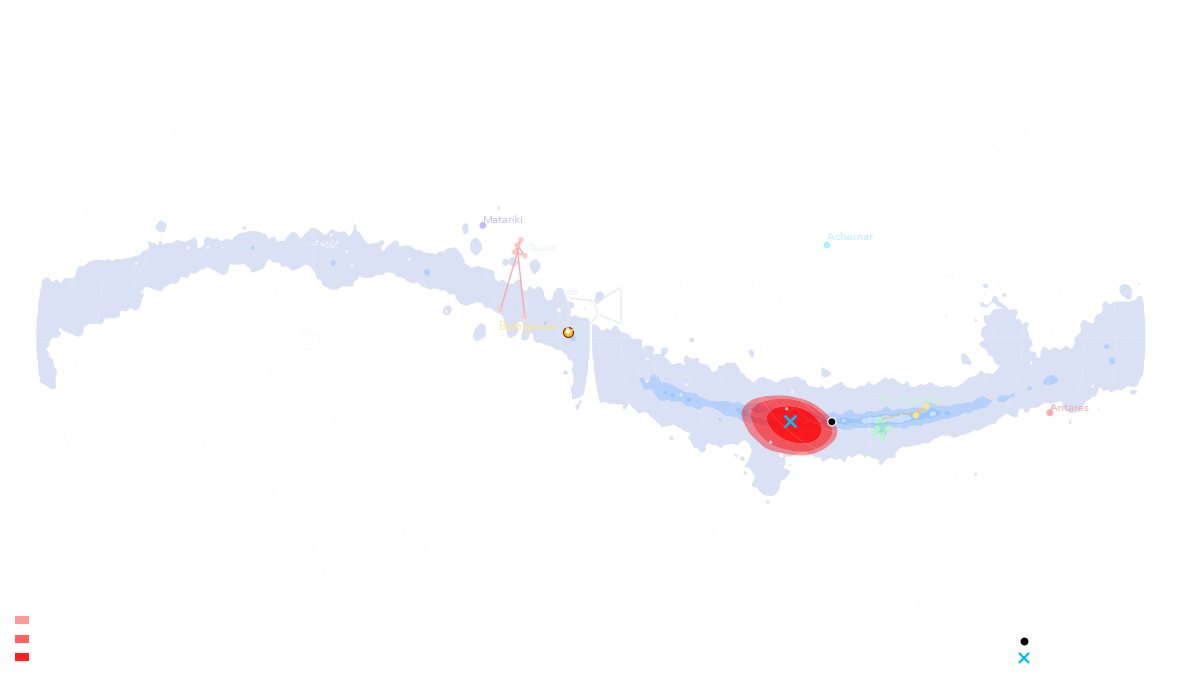

In [7]:
trainer_sky.run_parameter_estimation(signal_idx=1, d=5.0, fname_signal="../../poster-presentation/flow_sky_signal.png", fname_posterior="../../poster-presentation/flow_sky_posterior.png", fname_posterior_sky="../../poster-presentation/flow_sky_posterior_sky.png", background="black", font_family=font_family, font_name=font_name, export_on=False, transparent=True)


hThetaMulti Dataset - Parameter Bounds (4 parameters)
INTRINSIC PARAMETERS:

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [   -3.141593,     3.141593]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    10.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 2000
Multi-channel shape: (2000, 3, 256)
Parameter dimension: 4
Parameters include theta + sky: [ra, dec, d, polar_angle]
✓ Created validation dataset with 2000 signals
  Processed 400/2000 signals...
  Processed 800/2000 signals...
  Processed 1200/2000 signals...
  Processed 1600/2000 signals...
  Processed 2000/2000 signals...
Generating p-p coverage plot...
✓ Saved p-p coverage plot to ../../poster-presentation/flow_sky_pp_coverage.png


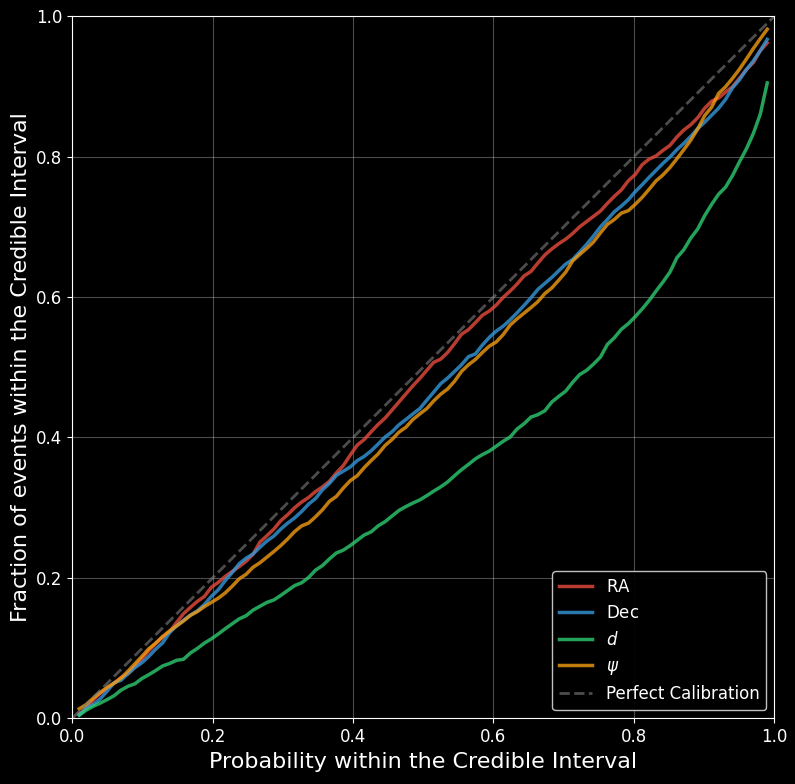

In [8]:
# trainer_sky.plot_pp_coverage_validation(
#     fname="../../poster-presentation/flow_sky_pp_coverage.png",
#     background="black",
#     font_family=font_family,
#     font_name=font_name,
#     transparent=True
# )